# AI Change Impact Analyzer — Phase 1: Single Workflow Agent

**Architecture:** One ReAct agent with 6 deterministic tools.  
**Example:** INR currency addition (`low-risk-inr-currency-design-doc.md`)  
**Output:** 7-section risk assessment report

```
PRD + Design Doc
       │
       ▼
   [ Agent ] ──── read_prd
   ReAct loop ─── read_design_doc
       │       ─── traverse_graph      ← graph.json (blast radius)
       │       ─── grep_codebase       ← src/ (verify call sites)
       │       ─── read_file           ← src/ (behavioral detail)
       │       ─── read_product_handbook
       ▼
  Risk Report (7 sections)
```

In [1]:
import os
import json
import subprocess
from pathlib import Path

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.agents import create_agent
from IPython.display import Image, display

print("✅ Imports OK")

✅ Imports OK


In [2]:
# Load API keys from the same .env used in Week3
ENV_PATH = os.path.expanduser("~/Documents/problem_first_ai/.env")
load_dotenv(ENV_PATH)

assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY not found — check ENV_PATH"
print(f"OPENAI_API_KEY : {os.environ['OPENAI_API_KEY'][:10]}...")

# Arize tracing — same setup as Week3
from arize.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor

tracer_provider = register(
    space_id=os.environ["ARIZE_SPACE_ID"],
    api_key=os.environ["ARIZE_API_KEY"],
    project_name="change-impact-analyzer-phase1",
)
LangChainInstrumentor(tracer_provider=tracer_provider).instrument()
print("🔭 Arize tracing active → project: change-impact-analyzer-phase1")

OPENAI_API_KEY : sk-proj-0S...
🔭 OpenTelemetry Tracing Details 🔭
|  Arize Project: change-impact-analyzer-phase1
|  Span Processor: BatchSpanProcessor
|  Collector Endpoint: otlp.arize.com
|  Transport: gRPC
|  Transport Headers: {'authorization': '****', 'api_key': '****', 'arize-space-id': '****', 'space_id': '****', 'arize-interface': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

🔭 Arize tracing active → project: change-impact-analyzer-phase1


## Configuration — Paths

This notebook lives in `notebook/` — the repo root is one level up.

In [16]:
# Repo root is one level above notebook/
REPO_ROOT = Path.cwd().parent

# Sanity check — if graphify-out isn't found, adjust manually
if not (REPO_ROOT / "graphify-out").exists():
    REPO_ROOT = Path.cwd()  # fallback: maybe running from repo root already

GRAPH_PATH    = REPO_ROOT / "graphify-out" / "graph.json"
HANDBOOK_PATH = REPO_ROOT / "product_handbook.pdf"
SRC_ROOT      = REPO_ROOT / "src"

# Example to analyze — swap these to run a different scenario (see last cell)
EXAMPLE_PRD        = REPO_ROOT / "prd_design_docs" / "filter-prd.md"
EXAMPLE_DESIGN_DOC = REPO_ROOT / "prd_design_docs" / "filter-design-doc.md"

print(f"REPO_ROOT  : {REPO_ROOT}")
print(f"Graph      : {GRAPH_PATH.exists()}")
print(f"Handbook   : {HANDBOOK_PATH.exists()}")
print(f"PRD        : {EXAMPLE_PRD.exists()}")
print(f"Design Doc : {EXAMPLE_DESIGN_DOC.exists()}")

REPO_ROOT  : /Users/mahashivamshu/Documents/capstone/ai_change_analyzer/team-7-microservices-demo
Graph      : True
Handbook   : True
PRD        : True
Design Doc : True


## Load Static Data (once)

Loaded into globals — tools reference these directly. No re-loading per call.

In [17]:
print("Loading dependency graph...")
with open(GRAPH_PATH, "r") as f:
    _graph_data = json.load(f)

GRAPH_NODES = _graph_data["nodes"]
GRAPH_LINKS = _graph_data["links"]
NODE_BY_ID  = {n['id']: n for n in GRAPH_NODES}  # fast lookup

print(f"✅ Graph: {len(GRAPH_NODES):,} nodes, {len(GRAPH_LINKS):,} links")

Loading dependency graph...
✅ Graph: 2,908 nodes, 3,401 links


In [18]:
from pypdf import PdfReader

print("Loading product handbook PDF...")
_reader = PdfReader(str(HANDBOOK_PATH))
HANDBOOK_TEXT = "\n\n".join(
    page.extract_text() or "" for page in _reader.pages
)
print(f"✅ Handbook: {len(_reader.pages)} pages, {len(HANDBOOK_TEXT):,} chars")

Loading product handbook PDF...
✅ Handbook: 25 pages, 44,305 chars


## Tool Definitions

All tools are **deterministic code** — no LLM inside them.  
The agent (LLM) calls them in whatever order it decides.

| Tool | Job |
|---|---|
| `read_prd` | Reads PRD markdown |
| `read_design_doc` | Reads Design Doc markdown |
| `traverse_graph` | BFS on graph.json → candidate services |
| `grep_codebase` | Confirms actual call sites (excludes genproto/) |
| `read_file` | Reads a source file for behavioral detail |
| `read_product_handbook` | Keyword search over handbook PDF |

In [19]:
@tool
def read_prd(prd_path: str) -> str:
    """Read a PRD markdown file. Returns full contents.
    Args:
        prd_path: Path relative to repo root or absolute.
    """
    path = Path(prd_path)
    if not path.is_absolute():
        path = REPO_ROOT / prd_path
    if not path.exists():
        return f"ERROR: PRD not found at {path}"
    return path.read_text()


@tool
def read_design_doc(design_doc_path: str) -> str:
    """Read a Design Doc markdown file. Returns full contents:
    Background, Current State, Proposed Solution, Affected Services,
    Deployment Plan, Risks.
    Args:
        design_doc_path: Path relative to repo root or absolute.
    """
    path = Path(design_doc_path)
    if not path.is_absolute():
        path = REPO_ROOT / design_doc_path
    if not path.exists():
        return f"ERROR: Design Doc not found at {path}"
    return path.read_text()


print("✅ read_prd, read_design_doc defined")

✅ read_prd, read_design_doc defined


In [20]:
@tool
def traverse_graph(service_name: str, hops: int = 1) -> str:
    """Find services connected to a given service in the dependency graph.

    Uses BFS traversal over graph.json edges.
    WARNING: Graph edges include generated protobuf stubs (genproto/ files).
    A service appearing here does NOT confirm it makes runtime calls.
    Always follow up with grep_codebase to verify actual callers.

    Args:
        service_name: Short name, e.g. 'currencyservice', 'frontend'
        hops: Traversal depth. Default 1 (direct neighbors only).
              Use 2 for proto changes that may have second-order callers.
    """
    service_node_ids = set(
        n['id'] for n in GRAPH_NODES
        if service_name.lower() in (n.get('source_file') or '').lower()
    )
    if not service_node_ids:
        return json.dumps({
            'error': f"No nodes found for '{service_name}'",
            'candidates': [],
            'tip': 'Use the exact folder name under src/'
        })

    frontier = service_node_ids.copy()
    visited  = service_node_ids.copy()
    for _ in range(hops):
        next_frontier = set()
        for link in GRAPH_LINKS:
            src, tgt = link['source'], link['target']
            if src in frontier and tgt not in visited:
                next_frontier.add(tgt)
            elif tgt in frontier and src not in visited:
                next_frontier.add(src)
        frontier = next_frontier
        visited |= next_frontier

    neighbor_ids = visited - service_node_ids
    neighbor_files = set(
        NODE_BY_ID[nid].get('source_file', '')
        for nid in neighbor_ids
        if nid in NODE_BY_ID and NODE_BY_ID[nid].get('source_file')
    )

    candidate_services = set()
    for f in neighbor_files:
        parts = f.replace('\\', '/').split('/')
        if 'src' in parts:
            idx = parts.index('src')
            if idx + 1 < len(parts):
                svc = parts[idx + 1]
                if svc != service_name:
                    candidate_services.add(svc)

    return json.dumps({
        'query_service': service_name,
        'hops': hops,
        'service_node_count': len(service_node_ids),
        'candidates': sorted(candidate_services),
        'warning': 'Candidates include genproto stubs. Verify with grep_codebase.'
    }, indent=2)


print("✅ traverse_graph defined")

✅ traverse_graph defined


In [21]:
@tool
def grep_codebase(service_names: str, pattern: str) -> str:
    """Search source code of specified services for a pattern.
    Excludes generated code (genproto/, node_modules/) automatically.
    Use to verify which candidates actually make runtime calls,
    not just have a generated proto stub.

    Args:
        service_names: Comma-separated list, e.g. 'frontend,checkoutservice'
        pattern: Extended regex, e.g. 'NewCurrencyServiceClient'
    """
    services = [s.strip() for s in service_names.split(',') if s.strip()]
    results = {}
    for svc in services:
        src_dir = SRC_ROOT / svc
        if not src_dir.exists():
            results[svc] = {'status': 'directory not found', 'match_count': 0, 'matches': []}
            continue
        cmd = [
            'grep', '-rn', '-E',
            '--include=*.go', '--include=*.js', '--include=*.py',
            '--include=*.java', '--include=*.cs',
            '--exclude-dir=genproto', '--exclude-dir=node_modules',
            pattern, str(src_dir)
        ]
        proc = subprocess.run(cmd, capture_output=True, text=True)
        raw = [l.strip() for l in proc.stdout.strip().split('\n') if l.strip()]
        clean = []
        for m in raw:
            try:
                c1 = m.index(':')
                c2 = m.index(':', c1 + 1)
                rel = Path(m[:c1]).relative_to(REPO_ROOT)
                clean.append(f"{rel}{m[c1:c2+1]}  {m[c2+1:].strip()}")
            except (ValueError, TypeError):
                clean.append(m)
        results[svc] = {
            'status': 'CONFIRMED CALLER' if raw else 'not a runtime caller (genproto stub only)',
            'match_count': len(raw),
            'matches': clean[:20]
        }
    return json.dumps(results, indent=2)


print("✅ grep_codebase defined")

✅ grep_codebase defined


In [22]:
@tool
def read_file(file_path: str) -> str:
    """Read a source file from the repository.
    Use to understand behavioral details:
    - How a service loads data (startup vs hot-reload)
    - Error handling for downstream calls
    - Specific gRPC call sites and on which code paths

    Args:
        file_path: Relative to repo root (e.g. 'src/currencyservice/server.js')
                   or absolute path.
    Returns file contents, truncated at 8000 chars if large.
    """
    path = Path(file_path)
    if not path.is_absolute():
        path = REPO_ROOT / file_path
    if not path.exists():
        return f"ERROR: Not found: {path}. Use paths relative to repo root."
    content = path.read_text(errors='replace')
    MAX = 8000
    if len(content) > MAX:
        return content[:MAX] + f"\n\n[... truncated — {len(content):,} total chars ...]"
    return content


@tool
def read_product_handbook(query: str) -> str:
    """Search the product handbook for sections relevant to the query.
    Use for: proto field rules, compliance requirements (PCI-DSS, GDPR),
    architectural constraints, or documented service behavior.

    Args:
        query: What you're looking for, e.g. 'currency conversion',
               'proto reserved fields', 'payment service constraints'
    """
    terms = query.lower().split()
    paras = [p.strip() for p in HANDBOOK_TEXT.split('\n\n') if len(p.strip()) > 80]
    def score(p): return sum(1 for t in terms if t in p.lower())
    top = sorted(paras, key=score, reverse=True)[:6]
    if not top or score(top[0]) == 0:
        return f"No relevant sections found for: '{query}'"
    return (f"Handbook sections for '{query}':\n\n" + "\n\n---\n\n".join(top))[:6000]


print("✅ read_file, read_product_handbook defined")

✅ read_file, read_product_handbook defined


## System Prompt

Tells the agent: what it is, the tool call order, and the exact 7-section output format.

In [23]:
SYSTEM_PROMPT = """\
You are an AI Change Impact Analyzer for Online Boutique — an 11-service
microservices system using gRPC and protobuf contracts.

Your job: Given a PRD and Design Doc, produce a grounded 7-section risk report.

WORKFLOW — follow this order every time
1. read_prd          → goals, requirements, success metrics
2. read_design_doc   → what is changing (files, services, proto fields)
3. traverse_graph    → candidate services in the blast radius (hops=1)
   Always note that graph edges include generated proto stubs.
4. grep_codebase     → verify which candidates actually make runtime calls.
   Search for the gRPC client constructor (e.g. NewCurrencyServiceClient).
   Drop any service with zero matches outside genproto/.
5. read_file         → entry point of changed service + each confirmed caller.
   Look for: data loading pattern, error handling, exact call sites.
6. read_product_handbook (optional) → compliance rules, proto constraints.

OUTPUT — produce exactly these 7 sections:

### Change Summary
One paragraph. What is changing, why, and what it achieves.

### Change Category
One of: Data/Config Change | Proto Change | New Service | Code Change |
Infrastructure Change | Mixed

### Affected Assets
Table: Asset | Type | Impact. Only list assets you verified.

### Dependency Paths
Call paths involving the changed service. For EVERY service returned by
traverse_graph, state its grep verdict explicitly:
  - Confirmed: "<service> — CONFIRMED CALLER (<N> matches)"
  - Dropped:   "<service> — not a runtime caller of <RPC> (grep: 0 matches, dropped)"
Do not silently omit candidates; name them and explain why they were kept or dropped.

### Risk Assessment
Risk Level: Low / Medium / High / Critical
Structural risk (blast radius) + behavioral risk (how failures propagate).
Reference specific file names you read.

Use these criteria — apply the HIGHEST matching level:

  Low    — Change touches ONLY static data or config files (JSON, YAML, env vars).
            No proto changes. No new services. No code logic added or removed.
            No new runtime dependencies. Rollback = revert one file.
            The fact that existing code READS the config file does NOT raise risk —
            the code path already exists and is already tested.
            Example: adding a currency entry to currency_conversion.json.

  Medium — Code changes in existing services (any number). Backward-compatible
            proto field addition NOT on the checkout or payment critical path.
            No new persistent store. No new service introduced.
            Blast radius ≤ 2 confirmed runtime callers.

  High   — Any of: new service introduced; new persistent store (DB, cache);
            new auth/identity concept; backward-compatible proto field that changes
            the checkout or payment critical path; ≥ 3 confirmed runtime callers
            affected; requires data migration or schema change.

  Critical — Breaking proto change; payment/security regression risk; irreversible
             data loss potential; no rollback path.

RULE: When a change introduces a new service OR a new persistent store, the
minimum risk level is High. Never assign Low or Medium in that case.

### Recommended Mitigation Steps
Numbered. Reference actual files, commands, monitoring targets.

### Summary
- Confidence Level: High/Medium/Low — explain what you verified vs. inferred
- Approval Recommendation: Approve | Approve with conditions | Needs re-design

RULES
- Only name files and services you actually verified.
- If you drop a candidate service (false positive), say so explicitly in
  Dependency Paths (e.g. "does not call SearchProducts — dropped").
- If grep_codebase returns "directory not found" for a proposed new service,
  state this explicitly in the report (e.g. "The proposed service was not found
  in src/ and could not be verified"). Confidence Level must be Medium or Low,
  not High, in that case.
- Confidence Level must reflect which tools you could actually call.
"""

print(f"System prompt: {len(SYSTEM_PROMPT)} chars")

System prompt: 2028 chars


## Build the Agent

In [24]:
model = init_chat_model("gpt-4o-mini", model_provider="openai")

TOOLS = [
    read_prd,
    read_design_doc,
    traverse_graph,
    grep_codebase,
    read_file,
    read_product_handbook,
]

# create_react_agent builds the LangGraph ReAct loop:
#   START → agent → tools → agent → ... → END
agent = create_agent(
    model,
    TOOLS,
    system_prompt=SYSTEM_PROMPT,        # langgraph >= 0.2
    # state_modifier=SYSTEM_PROMPT,  # use if 'prompt' raises TypeError
)

print(f"✅ Agent ready — tools: {[t.name for t in TOOLS]}")

✅ Agent ready — tools: ['read_prd', 'read_design_doc', 'traverse_graph', 'grep_codebase', 'read_file', 'read_product_handbook']


## Visualize the Graph

This is the **LangGraph execution graph** — not the dependency graph.  
`agent` loops back through `tools` until it decides it has enough context.

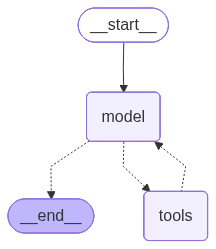

In [25]:
display(Image(agent.get_graph().draw_mermaid_png()))

## Run: By default runs, INR Currency Example, unless example is updated in cell 32

Expected tool sequence:
```
read_prd
read_design_doc
traverse_graph('currencyservice', hops=1)
  candidates: frontend, productcatalogservice, checkoutservice
grep_codebase('frontend,productcatalogservice,checkoutservice', 'NewCurrencyServiceClient|...')
  confirms: frontend, checkoutservice
  drops:    productcatalogservice  (zero matches outside genproto/)
read_file('src/currencyservice/server.js')   loading behavior
read_file('src/frontend/rpc.go')             call sites
read_file('src/checkoutservice/main.go')     pass-through
synthesize report
```

In [33]:
print("Running Phase 1 Agent...")
print(f"  PRD:        {EXAMPLE_PRD.relative_to(REPO_ROOT)}")
print(f"  Design Doc: {EXAMPLE_DESIGN_DOC.relative_to(REPO_ROOT)}")
print()

USER_MESSAGE = (
    "Analyze the following proposed change and produce a complete risk assessment report.\n\n"
    f"PRD path        : {EXAMPLE_PRD}\n"
    f"Design Doc path : {EXAMPLE_DESIGN_DOC}\n"
    f"Repository root : {REPO_ROOT}\n\n"
    "Follow the workflow: read PRD → Design Doc → traverse graph → "
    "grep codebase → read files → produce the 7-section report."
)

result = agent.invoke(
    {"messages": [HumanMessage(content=USER_MESSAGE)]},
    config={"recursion_limit": 30}
)

print(f"✅ Done. Messages in trace: {len(result['messages'])}")

Running Phase 1 Agent...
  PRD:        prd_design_docs/subscribe-and-save-prd.md
  Design Doc: prd_design_docs/subscribe-and-save-design-doc.md



Transient error StatusCode.UNAVAILABLE encountered while exporting traces to otlp.arize.com, retrying in 0.97s.
I0528 17:10:21.195761 3870323 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0528 17:10:21.201601 3870233 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0528 17:10:21.204401 3870350 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0528 17:10:21.210054 3870337 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0528 17:10:21.212013 3870386 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0528 17:10:21.213655 3870336 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0528 17:10:21.215036 3870413 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0528 17:10:23.270748 3870494 ev_poll_posix.cc:593] FD from fork parent 

✅ Done. Messages in trace: 29


## Tool Call Trace

See exactly what the agent called and in what order.

In [34]:
print("Tool Call Trace " + "-" * 52)
tool_call_count = 0
for msg in result['messages']:
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        for tc in msg.tool_calls:
            args_str = json.dumps(tc['args'])
            preview = args_str[:100] + '...' if len(args_str) > 100 else args_str
            print(f"  CALL  {tc['name']}({preview})")
            tool_call_count += 1
    elif hasattr(msg, 'name') and msg.name and type(msg).__name__ == 'ToolMessage':
        content = (msg.content or '').strip().replace('\n', ' ')
        print(f"     -> {content[:120]}{'...' if len(content) > 120 else ''}")

print(f"\nTotal tool calls: {tool_call_count}")

Tool Call Trace ----------------------------------------------------
  CALL  read_prd({"prd_path": "/Users/mahashivamshu/Documents/capstone/ai_change_analyzer/team-7-microservices-demo/p...)
  CALL  read_design_doc({"design_doc_path": "/Users/mahashivamshu/Documents/capstone/ai_change_analyzer/team-7-microservices...)
     -> # PRD: Subscribe & Save **Status:** Draft  **Author:** Product Team  **Date:** 2026-05-26  ## Problem Statement  Custome...
     -> # Design Doc: Subscribe & Save **Status:** Draft  **Author:** Engineering Team  **Date:** 2026-05-26  ## Background  Onl...
  CALL  traverse_graph({"service_name": "subscriptionservice", "hops": 1})
  CALL  traverse_graph({"service_name": "frontend", "hops": 1})
  CALL  traverse_graph({"service_name": "checkoutservice", "hops": 1})
  CALL  traverse_graph({"service_name": "productcatalogservice", "hops": 1})
  CALL  traverse_graph({"service_name": "paymentservice", "hops": 1})
  CALL  traverse_graph({"service_name": "emailservice", "ho

## Risk Assessment Report

In [35]:
final_report = result['messages'][-1].content
print("=" * 68)
print("  RISK ASSESSMENT REPORT")
print("=" * 68)
print(final_report)
print("=" * 68)

  RISK ASSESSMENT REPORT
### Change Summary
The proposed change introduces a subscription feature to the Online Boutique platform, allowing repeat customers to automate the reordering of products at specified cadences. This feature aims to increase customer retention and lifetime value by providing a user-friendly subscription process, including discounts for subscribers, a subscription management dashboard, and automated billing. The inclusion of self-service options for customers enhances experience and compliance with regulations such as FTC click-to-cancel requirements.

### Change Category
Mixed

### Affected Assets
| Asset                          | Type         | Impact                                                                                                                                      |
|--------------------------------|--------------|----------------------------------------------------------------------------------------------------------------------------------

## Save Report to File

In [36]:
from datetime import datetime

REPORTS_DIR = REPO_ROOT / "risk_assessments"
REPORTS_DIR.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
prd_stem  = EXAMPLE_PRD.stem                          # e.g. "filter-prd"
report_filename = f"{timestamp}_risk_assessment-{prd_stem}.md"
report_path     = REPORTS_DIR / report_filename

report_path.write_text(final_report)
print(f"✅ Report saved → {report_path.relative_to(REPO_ROOT)}")

✅ Report saved → risk_assessments/20260528_171055_risk_assessment-subscribe-and-save-prd.md


## Try a Different Scenario

Uncomment one scenario, then re-run the **Run** and **Report** cells above.

In [38]:
# ── Swap scenario and re-run the Run / Trace / Save cells ──────────────────
# Uncomment ONE block, then re-run: Run → Trace → Report → Save

# INR Currency (LOW RISK — original worked example)
# EXAMPLE_PRD        = REPO_ROOT / 'prd_design_docs' / 'inr-currency-prd.md'
# EXAMPLE_DESIGN_DOC = REPO_ROOT / 'prd_design_docs' / 'inr-currency-design-doc.md'

# Order History (HIGH RISK — new service + proto change + auth dependency)
# EXAMPLE_PRD        = REPO_ROOT / 'prd_design_docs' / 'order-history-prd.md'
# EXAMPLE_DESIGN_DOC = REPO_ROOT / 'prd_design_docs' / 'order-history-design-doc.md'

# Inventory Stock (NEW)
# EXAMPLE_PRD        = REPO_ROOT / 'prd_design_docs' / 'inventory-stock-prd.md'
# EXAMPLE_DESIGN_DOC = REPO_ROOT / 'prd_design_docs' / 'inventory-stock-design-doc.md'

# Shipping Estimate (NEW)
# EXAMPLE_PRD        = REPO_ROOT / 'prd_design_docs' / 'shipping-estimate-prd.md'
# EXAMPLE_DESIGN_DOC = REPO_ROOT / 'prd_design_docs' / 'shipping-estimate-design-doc.md'

# Subscribe & Save (COMPLEX — new service + payment vault + renewal worker)
EXAMPLE_PRD        = REPO_ROOT / 'prd_design_docs' / 'subscribe-and-save-prd.md'
EXAMPLE_DESIGN_DOC = REPO_ROOT / 'prd_design_docs' / 'subscribe-and-save-design-doc.md'

print("Active scenario →", EXAMPLE_PRD.stem)

Active scenario → subscribe-and-save-prd


## Run Current Scenario (end-to-end)

Uncomment a scenario above, then run this single cell — it replaces running the Run / Trace / Report / Save cells individually.

In [61]:
from datetime import datetime

# ── 1. Run agent ─────────────────────────────────────────────────────────────
print(f"Running scenario: {EXAMPLE_PRD.stem}")
print(f"  PRD        : {EXAMPLE_PRD.relative_to(REPO_ROOT)}")
print(f"  Design Doc : {EXAMPLE_DESIGN_DOC.relative_to(REPO_ROOT)}")
print()

USER_MESSAGE = (
    "Analyze the following proposed change and produce a complete risk assessment report.\n\n"
    f"PRD path        : {EXAMPLE_PRD}\n"
    f"Design Doc path : {EXAMPLE_DESIGN_DOC}\n"
    f"Repository root : {REPO_ROOT}\n\n"
    "Follow the workflow: read PRD → Design Doc → traverse graph → "
    "grep codebase → read files → produce the 7-section report."
)

result = agent.invoke(
    {"messages": [HumanMessage(content=USER_MESSAGE)]},
    config={"recursion_limit": 30},
)
print(f"✅ Done. Messages in trace: {len(result['messages'])}\n")

# ── 2. Tool call trace ────────────────────────────────────────────────────────
print("Tool Call Trace " + "-" * 52)
tool_call_count = 0
for msg in result["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            args_str = json.dumps(tc["args"])
            preview = args_str[:100] + "..." if len(args_str) > 100 else args_str
            print(f"  CALL  {tc['name']}({preview})")
            tool_call_count += 1
    elif hasattr(msg, "name") and msg.name and type(msg).__name__ == "ToolMessage":
        content = (msg.content or "").strip().replace("\n", " ")
        print(f"     -> {content[:120]}{'...' if len(content) > 120 else ''}")
print(f"\nTotal tool calls: {tool_call_count}\n")

# ── 3. Risk assessment report ─────────────────────────────────────────────────
final_report = result["messages"][-1].content
print("=" * 68)
print("  RISK ASSESSMENT REPORT")
print("=" * 68)
print(final_report)
print("=" * 68)

# ── 4. Save to file ───────────────────────────────────────────────────────────
REPORTS_DIR = REPO_ROOT / "risk_assessments"
REPORTS_DIR.mkdir(exist_ok=True)

timestamp       = datetime.now().strftime("%Y%m%d_%H%M%S")
report_path     = REPORTS_DIR / f"{timestamp}_risk_assessment-{EXAMPLE_PRD.stem}.md"
report_path.write_text(final_report)
print(f"\n✅ Report saved → {report_path.relative_to(REPO_ROOT)}")

Running scenario: subscribe-and-save-prd
  PRD        : prd_design_docs/subscribe-and-save-prd.md
  Design Doc : prd_design_docs/subscribe-and-save-design-doc.md



Transient error StatusCode.UNAVAILABLE encountered while exporting traces to otlp.arize.com, retrying in 1.00s.
I0529 18:43:39.255545 4311275 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0529 18:43:39.264388 4311308 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0529 18:43:39.268817 4311342 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0529 18:43:39.274147 4311375 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0529 18:43:39.279630 4311410 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0529 18:43:41.914760 4311572 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0529 18:43:41.921782 4311604 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
I0529 18:43:41.928318 4311640 ev_poll_posix.cc:593] FD from fork parent still in poll list

✅ Done. Messages in trace: 39

Tool Call Trace ----------------------------------------------------
  CALL  read_prd({"prd_path": "/Users/mahashivamshu/Documents/capstone/ai_change_analyzer/team-7-microservices-demo/p...)
  CALL  read_design_doc({"design_doc_path": "/Users/mahashivamshu/Documents/capstone/ai_change_analyzer/team-7-microservices...)
     -> # PRD: Subscribe & Save **Status:** Draft  **Author:** Product Team  **Date:** 2026-05-26  ## Problem Statement  Custome...
     -> # Design Doc: Subscribe & Save **Status:** Draft  **Author:** Engineering Team  **Date:** 2026-05-26  ## Background  Onl...
  CALL  traverse_graph({"service_name": "subscriptionservice", "hops": 1})
     -> {"error": "No nodes found for 'subscriptionservice'", "candidates": [], "tip": "Use the exact folder name under src/"}
  CALL  traverse_graph({"service_name": "checkoutservice", "hops": 1})
     -> {   "query_service": "checkoutservice",   "hops": 1,   "service_node_count": 442,   "candidates": [     

## Debug Helpers

Call tools directly to verify they work before running the full agent.

In [ ]:
# Test traverse_graph directly
out = traverse_graph.invoke({'service_name': 'currencyservice', 'hops': 1})
print("traverse_graph(currencyservice, hops=1):")
print(out)

In [ ]:
# Test grep_codebase directly
out = grep_codebase.invoke({
    'service_names': 'frontend,productcatalogservice,checkoutservice',
    'pattern': 'NewCurrencyServiceClient'
})
parsed = json.loads(out)
for svc, info in parsed.items():
    print(f"{svc:30s}: {info['status']} ({info['match_count']} matches)")